# First Steps in Python: Markov Processes and Decisions

We will build two small models from the first lecture, from simple to more involved:

1. **Employment/unemployment:** store states and probabilities, then build a Markov-process object that simulates a worker's path.
2. **Maze navigation:** represent a location as a state vector and let a policy choose an action.

No previous Python experience is assumed. Read each explanation before running its code. Work through the first model together; use the maze for guided practice. Allow about 50–60 minutes for the guided work, followed by a separate cake-eating MDP exercise.

[Open in Colab](https://colab.research.google.com/github/YaolangZhong/U_Tokyo_Comp_Econ_Course/blob/main/weeks/week_01/lab/starter/markov_processes.ipynb) · [Lecture slides](https://yaolangzhong.github.io/U_Tokyo_Comp_Econ_Course/downloads/week_01/lecture/Introduction_to_Markov_Decision_Processes.pdf)

## 1. Run your first cell

In Colab, sign in, save a copy in Drive, and connect to a standard CPU runtime. NumPy and Matplotlib are available in the standard Colab environment; no data files or Drive mounting are needed.

A **text cell** explains the work. A **code cell** contains instructions. Click its play button or press **Shift+Enter**. Run cells from top to bottom: later cells use values created earlier.

`import` loads a **module** (a collection of tools). `print(...)` is a **function call**: it performs an operation using the values inside parentheses, called **arguments**. Text between quotes is a **string**. The first cell shows the Python version in this runtime.

In [1]:
import sys
print("Python version:", sys.version.split()[0])

Python version: 3.12.14


`sys.version` is version information. A dot accesses information or an operation belonging to an object. `.split()` separates the text into words; `[0]` selects the first word. Python counts positions from **zero**.

## 2. States: names, lists, and positions

The employment chain has two states, ordered as unemployed (`U`), employed (`E`), just as in the lecture.

A **variable** gives a name to a value. `=` assigns a value; it is not an equality test. A **list**, written with square brackets, keeps values in order. A line starting with `#` is a **comment** for readers.

In [2]:
# The ordering must be the same in every probability vector and matrix.
states = ["Unemployed", "Employed"]
current_state = 0
print("State names:", states)
print("Current state:", states[current_state])

State names: ['Unemployed', 'Employed']
Current state: Unemployed


`current_state` is an **integer** (`int`), used here as a state index. `states[0]` selects unemployment; `states[1]` selects employment.

**Try it:** change `current_state` to `1` and rerun the cell. Only the selected label changes; the list still contains both possible states.

## 3. One transition-probability vector

Suppose an unemployed worker finds a job next month with probability $\alpha=0.20$. These are illustrative probabilities, not estimates.

Conditional on being unemployed today, the next-state probabilities are

$$p_U=(1-\alpha,\alpha)=(0.80,0.20).$$

A number with a decimal point is a **float**. NumPy is a **package** for numerical work. `import numpy as np` loads it under the shorter name `np`. `np.array(...)` turns a list into a numerical **array**, which we use to represent a vector.

In [3]:
import numpy as np

alpha = 0.20
p_unemployed = np.array([1 - alpha, alpha])
print("Next-state probabilities [U, E]:", p_unemployed)
print("Probability of finding a job:", p_unemployed[1])
print("Sum:", p_unemployed.sum())

Next-state probabilities [U, E]: [0.8 0.2]
Probability of finding a job: 0.2
Sum: 1.0


`.sum()` is a **method**: a function belonging to this array. A valid probability vector has nonnegative entries and sums to one.

A **Boolean** is `True` or `False`. `np.all(...)` checks every entry; `np.allclose(...)` checks approximate equality, allowing tiny rounding differences. `assert` stops execution if its condition is false.

In [4]:
print("All probabilities are nonnegative:", np.all(p_unemployed >= 0))
assert np.all(p_unemployed >= 0)
assert np.allclose(p_unemployed.sum(), 1)

All probabilities are nonnegative: True


## 4. From a vector to a transition matrix

An employed worker loses their job with probability $\delta=0.05$. Combine the probability vectors for both current states:

$$P=\begin{pmatrix}1-\alpha&\alpha\\\delta&1-\delta\end{pmatrix}.$$

Each inner list below becomes one row. **Rows mean today's state; columns mean next month's state**, ordered `[U, E]`. `P[0, 1]` selects row 0, column 1: unemployment to employment.

In [5]:
delta = 0.05
P = np.array([
    [1 - alpha, alpha],
    [delta, 1 - delta]
])
print("Transition matrix:")
print(P)
print("Unemployed to employed:", P[0, 1])
print("Employed to unemployed:", P[1, 0])
print("Row sums:", P.sum(axis=1))
assert np.all(P >= 0)
assert np.allclose(P.sum(axis=1), 1)

Transition matrix:
[[0.8  0.2 ]
 [0.05 0.95]]
Unemployed to employed: 0.2
Employed to unemployed: 0.05
Row sums: [1. 1.]


`axis=1` tells `.sum()` to add across each row. It is a **keyword argument**: a setting supplied by name.

We now have a time-homogeneous **Markov chain**: next month's probabilities depend on the current state, not on earlier states, and we use the same matrix each month. A Markov chain is a Markov process with a discrete state space.

## 5. State versus state-probability vector

A worker's realized state is either `U` or `E`. A **probability vector** describes uncertainty about that state:

$$\mu_0=(0.60,0.40),\qquad \mu_1=\mu_0P.$$

The first entry of $\mu_0$ is a 60% probability of unemployment. It is not a worker who is “60% unemployed.” The same vector can describe population shares under the common transition rule.

NumPy uses a one-dimensional array here. Placing it on the left in `mu0 @ P` matches the lecture's **row-vector convention**. `@` means matrix multiplication; `*` means ordinary or entry-by-entry multiplication.

In [6]:
mu0 = np.array([0.60, 0.40])
mu1 = mu0 @ P
print("Initial probabilities:", mu0)
print("Next-month probabilities:", mu1)

# Two ways to end up unemployed next month.
unemployment_next = mu0[0] * P[0, 0] + mu0[1] * P[1, 0]
print("Unemployment, calculated separately:", unemployment_next)
assert np.allclose(mu1[0], unemployment_next)
assert np.allclose(mu1.sum(), 1)

Initial probabilities: [0.6 0.4]
Next-month probabilities: [0.5 0.5]
Unemployment, calculated separately: 0.5


With the starting inputs, the result is `[0.50, 0.50]`. Explain the two terms in the calculation before continuing.

## 6. Draw one next state

Updating a distribution calculates probabilities. **Simulation** instead draws one possible outcome using those probabilities.

`np.random.default_rng(7)` creates a random-number generator. The **seed** `7` makes the sequence repeatable in the same software setup. `rng.choice(2, p=...)` chooses state index `0` or `1` using the given probabilities.

In [7]:
rng = np.random.default_rng(7)
current_state = 0
next_state = rng.choice(2, p=P[current_state])
print("Today:", states[current_state])
print("One simulated next month:", states[next_state])

Today: Unemployed
One simulated next month: Unemployed


`P[current_state]` selects the entire row for today's state. One simulated worker need not match the population probabilities.

## 7. Put the model into a class

A **class** is a blueprint that keeps a model's data and operations together. A particular model created from it is an **object** (or instance).

We will create `MarkovProcess` with:

- **Attributes** `states` and `P`: the data stored by the object.
- A **method** `simulate(...)`: instructions that draw a state path.

Read these Python terms before the definition:

- `class` defines the blueprint; `def` defines a function or method.
- `__init__` runs when an object is created. `self` refers to that object; `self.P` stores its matrix.
- `for ... in range(periods)` repeats a block `periods` times. **Indentation** marks the instructions inside the loop or method.
- `.append(...)` adds an item to a list. `return` sends the result back to the caller.
- `seed=7` supplies a default value if no seed is passed.

In [8]:
class MarkovProcess:
    def __init__(self, states, P):
        self.states = states
        self.P = np.array(P)
        assert self.P.shape == (len(states), len(states))
        assert np.all(self.P >= 0)
        assert np.allclose(self.P.sum(axis=1), 1)

    def simulate(self, initial_state, periods, seed=7):
        rng = np.random.default_rng(seed)
        state = initial_state
        path = [state]
        for period in range(periods):
            state = rng.choice(len(self.states), p=self.P[state])
            path.append(state)
        return np.array(path)

`len(states)` counts the state labels; `.shape` reports an array's dimensions. `==` tests equality. The checks require one row and column per state and valid probabilities.

Running the class definition creates the blueprint. The next cell creates a model and calls its simulation method. `initial_state=0` means that this worker starts unemployed with certainty; it is different from the uncertain initial distribution `mu0` above.

In [9]:
employment = MarkovProcess(states, P)
path = employment.simulate(initial_state=0, periods=24, seed=7)
print("State indices from month 0 to month 24:")
print(path)
print("Initial state:", employment.states[path[0]])
print("Final state:", employment.states[path[-1]])

State indices from month 0 to month 24:
[0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
Initial state: Unemployed
Final state: Unemployed


`path[-1]` selects the last entry: negative positions count backward from the end.

## 8. See the simulated path

Matplotlib is a plotting package; we give its `pyplot` module the alias `plt`. `range(len(path))` supplies month numbers. A step plot is suitable for discrete states.

This line shows **one worker's realized states**, not a probability vector. Its values are state labels `0` and `1`, not unemployment rates.

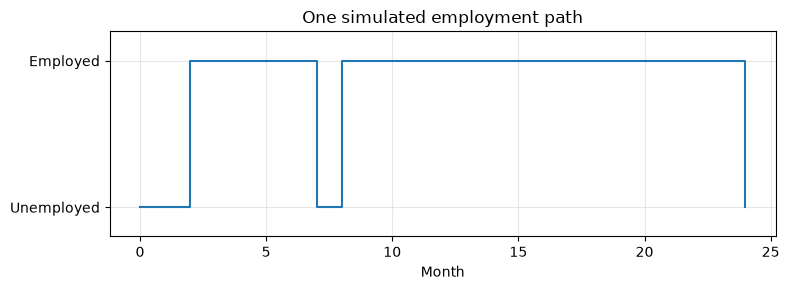

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.step(range(len(path)), path, where="post")
plt.yticks([0, 1], states)
plt.xlabel("Month")
plt.title("One simulated employment path")
plt.ylim(-0.2, 1.2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Practice: change the model

Before running, predict the effect of increasing the job-finding probability. `P_trial` is a new matrix; changing a number does not automatically rebuild previously created arrays or objects.

In [11]:
alpha_trial = 0.40
P_trial = np.array([
    [1 - alpha_trial, alpha_trial],
    [delta, 1 - delta]
])
employment_trial = MarkovProcess(states, P_trial)
print("Baseline next-month distribution:", mu0 @ employment.P)
print("Higher job-finding probability:", mu0 @ employment_trial.P)
print("A new simulated path:", employment_trial.simulate(0, 24, seed=7))

Baseline next-month distribution: [0.5 0.5]
Higher job-finding probability: [0.38 0.62]
A new simulated path: [0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]


Try changing the seed. Why can a simulated path change while `mu0 @ P` stays the same? For `alpha_trial = 0.40`, the new one-month distribution is `[0.38, 0.62]`.

## 9. An MDP: a state vector and chosen actions

The lecture's maze adds an **action** to the transition. We use a smaller **3 × 3 maze**, with one wall, but keep the lecture's rules:

- State: the current free cell, represented by the vector `[row, column]`.
- Actions: up, down, left, right.
- Hitting a wall or boundary leaves the position unchanged.
- The goal is absorbing. Reward is `-1` for every move made outside the goal, including the move into it, and `0` thereafter.

Rows and columns start at zero. Row 0 is the top; row 2 is the bottom. Start at `[2, 0]`, with goal `[0, 2]` and wall `[1, 1]`.

```text
.  .  G
.  #  .
S  .  .
```

This **state vector describes one location**. It is not the probability vector `mu0`, and its entries need not sum to one.

In [12]:
state = np.array([2, 0])
move_up = np.array([-1, 0])
print("Current location:", state)
print("After moving up:", state + move_up)

Current location: [2 0]
After moving up: [1 0]


NumPy adds these arrays entry by entry. A **dictionary** stores named values: `moves["up"]` looks up the displacement attached to the string `"up"`.

A **policy** is a function that takes the current state as input and returns an action. `if` checks a condition; `else` handles the alternative. This simple policy goes up first, then right; from our chosen start it avoids the central wall. We are specifying a policy, not solving for an optimal one.

In [13]:
def up_then_right(state):
    if state[0] > 0:
        return "up"
    else:
        return "right"

print("Action at the start:", up_then_right(np.array([2, 0])))
print("Action at the top-left corner:", up_then_right(np.array([0, 0])))

Action at the start: up
Action at the top-left corner: right


## 10. Build the maze object

The `MazeMDP` class has two main methods:

- `step(state, action)` applies the movement rule and returns the next state and reward.
- `simulate(policy, initial_state, periods)` repeatedly asks the policy for an action, then applies `step`.

New syntax used below:

- `{...}` constructs a dictionary. `np.array_equal(a, b)` tests whether two arrays have equal entries.
- `and` requires both conditions to hold; `not` reverses a Boolean.
- `a, b = ...` **unpacks** two returned values into two names.
- `.copy()` keeps a separate copy of an array.

Read the movement rule first, then the simulation loop. The transition here is deterministic: each state/action pair selects exactly one next cell. An MDP can also have random transitions.

In [14]:
class MazeMDP:
    def __init__(self):
        self.goal = np.array([0, 2])
        self.wall = np.array([1, 1])
        self.beta = 0.95
        self.moves = {
            "up": np.array([-1, 0]),
            "down": np.array([1, 0]),
            "left": np.array([0, -1]),
            "right": np.array([0, 1])
        }

    def step(self, state, action):
        if np.array_equal(state, self.goal):
            return state.copy(), 0
        next_state = state + self.moves[action]
        inside = np.all(next_state >= 0) and np.all(next_state < 3)
        if not inside or np.array_equal(next_state, self.wall):
            next_state = state.copy()
        return next_state, -1

    def simulate(self, policy, initial_state, periods):
        state = np.array(initial_state)
        path = [state.copy()]
        rewards = []
        for period in range(periods):
            action = policy(state)
            state, reward = self.step(state, action)
            path.append(state.copy())
            rewards.append(reward)
        return np.array(path), np.array(rewards)

`self.beta` stores the lecture's discount factor, with $0<\beta<1$. We do not calculate discounted values or optimize policies in this notebook.

Notice that the simulation receives `up_then_right` **without parentheses**: we pass the function itself so that the method can call it on every new state.

In [15]:
maze = MazeMDP()
maze_path, rewards = maze.simulate(up_then_right, initial_state=[2, 0], periods=6)
print("Locations, including the start:")
print(maze_path)
print("Rewards for the six moves:", rewards)

Locations, including the start:
[[2 0]
 [1 0]
 [0 0]
 [0 1]
 [0 2]
 [0 2]
 [0 2]]
Rewards for the six moves: [-1 -1 -1 -1  0  0]


The first four moves reach the goal. The remaining two moves stay there and receive zero reward. The array of locations has seven rows: one initial state plus six transitions.

## 11. Visualize the path, then change the policy

`maze_path[:, 1]` selects every row (`:`) and column 1, the horizontal coordinate. Column 0 is the vertical coordinate. The plot reverses the vertical axis so row 0 appears at the top, as in the grid.

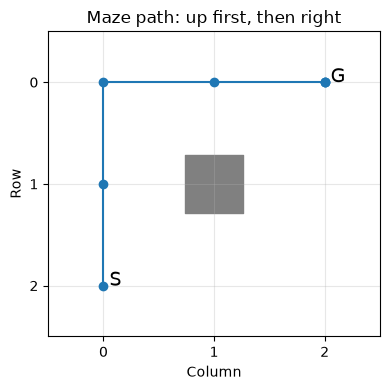

In [16]:
plt.figure(figsize=(4, 4))
plt.scatter(maze.wall[1], maze.wall[0], marker="s", s=1800, color="gray", label="Wall")
plt.plot(maze_path[:, 1], maze_path[:, 0], "o-", label="Policy path")
plt.text(0, 2, " S", fontsize=14)
plt.text(2, 0, " G", fontsize=14)
plt.xticks([0, 1, 2])
plt.yticks([0, 1, 2])
plt.xlim(-0.5, 2.5)
plt.ylim(2.5, -0.5)
plt.xlabel("Column")
plt.ylabel("Row")
plt.title("Maze path: up first, then right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Now keep the MDP fixed and change only its policy. Predict the path before running. Why does this policy stop making progress?

In [17]:
def always_right(state):
    return "right"

stuck_path, stuck_rewards = maze.simulate(always_right, [2, 0], periods=6)
print("Always-right locations:")
print(stuck_path)
print("Rewards:", stuck_rewards)

Always-right locations:
[[2 0]
 [2 1]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]]
Rewards: [-1 -1 -1 -1 -1 -1]


### Your exercise

1. Write a new policy in the cell below that goes **right first, then up**. Follow the same `if` / `else` structure as `up_then_right`.
2. Simulate it from `[2, 0]` and check the first four moves on paper.
3. Try `maze.step(np.array([1, 0]), "right")`. Explain why the next state is unchanged.
4. Compare the two models: what selects the next employment state, and what selects an action in the maze?

This cell contains comments so the supplied notebook runs from top to bottom. Replace the comments with your policy and simulation call.

In [18]:
# Define your right_then_up(state) policy here.
# Then call maze.simulate(right_then_up, [2, 0], periods=6).
# Print the returned path and rewards.

### My observations

Edit this text cell:

- A Python list and a NumPy array both store values; the array helped me to...
- `P[0, 1]` means...
- The vector `mu0` and the vector `[row, column]` describe different things because...
- A class stores...; a method does...
- `employment.simulate(...)` draws...; `maze.simulate(...)` calls the policy to...
- My new policy and the path it produced:

## 12. Independent MDP exercise: cake eating

Now build a different MDP yourself using the lecture's **cake-eating** problem. Use the maze class as a guide, but write the new transition and policy. Allow about 20 minutes, or finish after class.

For this exercise, restrict the lecture's continuous stock and consumption to **whole units**:

- **State** $k_t$: remaining cake, initially 4 units; $\mathcal S=\{0,1,2,3,4\}$.
- **Action** $c_t$: whole units consumed, with $0\leq c_t\leq k_t$.
- **Transition** $k_{t+1}=k_t-c_t$.
- **Reward** $r(k_t,c_t)=\sqrt{c_t}$, computed with `np.sqrt(action)`.
- **Discount factor** $\beta=0.95$. Store it in the model; we will study discounted values and optimal policies in later lectures.
- At zero cake, only action 0 is feasible; the stock stays zero and reward is zero.

**Task A — complete the model.** Implement `step` and `simulate` in the scaffold below. `step` should check that the action is feasible (use `assert`), then return the next state and reward. `simulate` should call the policy at every step and return the state path and rewards, as the maze method does.

`pass` is Python's “do nothing” placeholder. It lets an unfinished definition run, but it does not implement the method. Replace every `pass` below with your code.

In [19]:
class CakeMDP:
    def __init__(self):
        self.beta = 0.95

    def step(self, state, action):
        # Check: action is a whole number between 0 and state.
        # Return: next state, reward.
        pass

    def simulate(self, policy, initial_state, periods):
        # Start a path and reward list.
        # Each period: choose an action, step, and record the results.
        # Return two NumPy arrays, as in MazeMDP.simulate.
        pass


def consume_one(state):
    # Consume one unit if cake remains; otherwise consume zero.
    pass

**Task B — apply a policy and verify the path.** Complete `consume_one`, create your model, and simulate five periods from 4 units.

Before running, write the expected path on paper. There are **six states** (including the initial stock) and **five rewards**. The checks below should pass once your implementation is complete. Uncomment them together by removing the leading `# ` on each line.

A call such as `cake.step(4, 2)` should give next state 2 and reward $\sqrt{2}$. An action larger than the available cake must be rejected.

In [20]:
# Run these checks after completing Task A and the policy.
# cake = CakeMDP()
# cake_path, cake_rewards = cake.simulate(consume_one, initial_state=4, periods=5)
# print("Cake remaining:", cake_path)
# print("Rewards:", cake_rewards)
# assert np.array_equal(cake_path, [4, 3, 2, 1, 0, 0])
# assert np.allclose(cake_rewards, [1, 1, 1, 1, 0])
# next_stock, reward = cake.step(4, 2)
# assert next_stock == 2 and np.isclose(reward, np.sqrt(2))
# next_stock, reward = cake.step(0, 0)
# assert next_stock == 0 and reward == 0

**Task C — change only the policy.** Write `consume_two(state)`: consume two units if at least two remain, one if only one remains, and zero otherwise. Simulate it from 4 units and compare the stock and reward paths with `consume_one`.

### My MDP exercise answers

- My two policies and their stock paths:
- How feasible consumption depends on the state:
- What happens after the cake is exhausted:
- Which code represents the environment, and which code represents the policy:
- Why different reward paths alone do not establish which policy is optimal:


In [21]:
# Define consume_two(state), then simulate it with the same CakeMDP object.
# Print and compare the stock and reward paths.

## 13. Save and reproduce your work

Restart the runtime/kernel and run all cells from the top. This checks that your work does not depend on values left from earlier runs. Save your answers and download the `.ipynb` file.

For the local setup homework, install `numpy`, `matplotlib`, and `ipykernel` in your project environment and select it in VS Code. The companion `markov_processes.py` contains the notebook's supplied code cells in the same order. Run it and check that its baseline probability vector and maze path match the notebook. Keep the files and a short README in your Git repository, then commit and push.

### Reading

- Course lecture: *Introduction to Markov Decision Processes*, employment/unemployment, transition properties, and maze escape. The employment probabilities and smaller maze used here are teaching choices.
- [Python tutorial](https://docs.python.org/3/tutorial/): revisit Python terminology as needed.
- [NumPy: the absolute basics for beginners](https://numpy.org/doc/stable/user/absolute_beginners.html).